# Economic Development Analytics
### Data Source: World Bank — World Development Indicators (WDI)
### Countries: India, China, USA, Brazil, Nigeria, Germany, Bangladesh, Ethiopia
### Period: 2000–2024
### Tools: Python, NumPy, **Polars**, Matplotlib

### Imports & Version Check

In [1]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import warnings
warnings.filterwarnings('ignore')

print(f"Polars  : {pl.__version__}")
print(f"NumPy   : {np.__version__}")

Polars  : 1.41.2
NumPy   : 2.4.6


## Load CSV with Polars

In [2]:

df_raw = pl.read_csv(
    "WDI_data.csv",
    null_values=[".."]
) # null_values tells Polars to treat '..' (World Bank missing marker) as null

print("Shape:", df_raw.shape)
print("\nColumns:", df_raw.columns)
df_raw.head(5)

Shape: (108, 22)

Columns: ['Country Name', 'Country Code', 'Series Name', 'Series Code', '2000 [YR2000]', '2001 [YR2001]', '2002 [YR2002]', '2003 [YR2003]', '2004 [YR2004]', '2005 [YR2005]', '2006 [YR2006]', '2007 [YR2007]', '2008 [YR2008]', '2017 [YR2017]', '2018 [YR2018]', '2019 [YR2019]', '2020 [YR2020]', '2021 [YR2021]', '2022 [YR2022]', '2023 [YR2023]', '2024 [YR2024]', '2025 [YR2025]']


Country Name,Country Code,Series Name,Series Code,2000 [YR2000],2001 [YR2001],2002 [YR2002],2003 [YR2003],2004 [YR2004],2005 [YR2005],2006 [YR2006],2007 [YR2007],2008 [YR2008],2017 [YR2017],2018 [YR2018],2019 [YR2019],2020 [YR2020],2021 [YR2021],2022 [YR2022],2023 [YR2023],2024 [YR2024],2025 [YR2025]
str,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""World""","""WLD""","""Unemployment, total (% of tota…","""SL.UEM.TOTL.ZS""",6.111266,6.189808,6.411809,6.483909,6.329692,6.223899,5.97374,5.774809,5.824044,5.897888,5.75952,5.588223,6.587314,6.045191,5.234262,4.849571,4.805873,4.790972
"""World""","""WLD""","""Poverty headcount ratio at $3.…","""SI.POV.DDAY""",36.2,35.3,33.7,32.2,30.3,28.3,27.0,25.3,24.1,11.8,11.1,null,11.4,11.3,10.9,10.6,10.4,null
"""World""","""WLD""","""GDP (current US$)""","""NY.GDP.MKTP.CD""",3.3898e13,3.3690e13,3.4992e13,3.9243e13,4.4225e13,4.7900e13,5.1924e13,5.8526e13,6.4312e13,8.1839e13,8.7051e13,8.8483e13,8.5913e13,9.8140e13,1.0225e14,1.0674e14,1.1098e14,null
"""World""","""WLD""","""GDP growth (annual %)""","""NY.GDP.MKTP.KD.ZG""",4.555062,2.038553,2.311071,3.093835,4.501845,4.054536,4.47617,4.413845,2.092395,3.45183,3.273958,2.679118,-2.899223,6.41335,3.403055,2.948595,2.87195,null
"""World""","""WLD""","""GDP per capita (current US$)""","""NY.GDP.PCAP.CD""",5501.264218,5394.685125,5530.021043,6122.434461,6811.481958,7284.31331,7796.34931,8677.571027,9415.357861,10747.76431,11309.38308,11376.08181,10937.68462,12390.66867,12798.16585,13236.7164,13631.20431,null


### Check how much data exists in future(latest) years

In [3]:
# Check how much data exists in future years
future_cols = ['2023 [YR2023]', '2024 [YR2024]', '2025 [YR2025]']

for col in future_cols:
    if col in df_raw.columns:
        non_null = df_raw.select(pl.col(col).is_not_null().sum()).item()
        # .select() picks the column, .is_not_null() flags non-null, .sum() counts them
        print(f"{col[:4]}: {non_null} non-null values out of {df_raw.height} rows")

2023: 91 non-null values out of 108 rows
2024: 82 non-null values out of 108 rows
2025: 10 non-null values out of 108 rows


### Clean Column Names & Unpivot (Wide → Long)


In [4]:
import re

# Clean column names — strip ' [YRxxxx]' suffix
# rename via dict built from list comprehension
rename_map = {
    col: re.sub(r'\s*\[YR\d+\]', '', col).strip()
    for col in df_raw.columns
}
df = df_raw.rename(rename_map)

#Drop 2025 (sparse data)
df = df.drop('2025') if '2025' in df.columns else df

#Identify id cols and year cols
id_cols   = ['Country Name', 'Country Code', 'Series Name', 'Series Code']
year_cols = [c for c in df.columns if c.isdigit()]

print("Year columns found:", year_cols)
print("Countries:", df['Country Name'].unique().to_list())
print("Indicators:", df['Series Name'].unique().to_list())

Year columns found: ['2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024']
Countries: ['China', 'Nigeria', 'United States', 'Ethiopia', 'Bangladesh', 'Germany', 'India', 'World', 'Brazil']
Indicators: ['Life expectancy at birth, total (years)', 'Population, total', 'Exports of goods and services (% of GDP)', 'Unemployment, total (% of total labor force) (modeled ILO estimate)', 'Gini index', 'Access to electricity (% of population)', 'Inflation, consumer prices (annual %)', 'School enrollment, primary (% gross)', 'GDP growth (annual %)', 'Poverty headcount ratio at $3.00 a day (2021 PPP) (% of population)', 'GDP (current US$)', 'GDP per capita (current US$)']



## Unpivot & Type Casting


In [5]:
df_long = df.unpivot(
    on=year_cols,
    index=id_cols,
    variable_name='Year',
    value_name='Value'
)


df_long = df_long.with_columns([
    pl.col('Year').cast(pl.Int32),
    pl.col('Value').cast(pl.Float64, strict=False)  # strict=False = coerce errors to null
])

#Drop null values
df_long = df_long.drop_nulls(subset=['Value'])

print("Shape after unpivot + clean:", df_long.shape)
df_long.head(5)

Shape after unpivot + clean: (1587, 6)


Country Name,Country Code,Series Name,Series Code,Year,Value
str,str,str,str,i32,f64
"""World""","""WLD""","""Unemployment, total (% of tota…","""SL.UEM.TOTL.ZS""",2000,6.111266
"""World""","""WLD""","""Poverty headcount ratio at $3.…","""SI.POV.DDAY""",2000,36.2
"""World""","""WLD""","""GDP (current US$)""","""NY.GDP.MKTP.CD""",2000,3.3898e13
"""World""","""WLD""","""GDP growth (annual %)""","""NY.GDP.MKTP.KD.ZG""",2000,4.555062
"""World""","""WLD""","""GDP per capita (current US$)""","""NY.GDP.PCAP.CD""",2000,5501.264218


### Rename Columns & Map Short Indicator Names

In [6]:
# Rename columns for convenience
df_long = df_long.rename({
    'Country Name': 'Country',
    'Country Code': 'Code',
    'Series Name' : 'Indicator',
    'Series Code' : 'Indicator_Code'
})

# Short indicator name mapping
indicator_map = {
    'Unemployment, total (% of total labor force) (modeled ILO estimate)': 'Unemployment %',
    'Poverty headcount ratio at $3.00 a day (2021 PPP) (% of population)': 'Poverty %',
    'GDP (current US$)'                                                   : 'GDP',
    'GDP growth (annual %)'                                               : 'GDP Growth %',
    'GDP per capita (current US$)'                                        : 'GDP per Capita',
    'Inflation, consumer prices (annual %)'                               : 'Inflation %',
    'Gini index'                                                          : 'Gini Index',
    'Population, total'                                                   : 'Population',
    'Life expectancy at birth, total (years)'                             : 'Life Expectancy',
    'School enrollment, primary (% gross)'                                : 'School Enrollment %',
    'Exports of goods and services (% of GDP)'                           : 'Exports % GDP',
    'Access to electricity (% of population)'                             : 'Electricity Access %'
}

df_long = df_long.with_columns(
    pl.col('Indicator').replace(indicator_map).alias('Indicator_Short')
)

print("Final shape:", df_long.shape)
print("\nSample:")
print(df_long.head(8))

#Data availability per indicator
print("\nData availability per indicator (non-null count):")
print(
    df_long
    .group_by('Indicator_Short')
    .agg(pl.col('Value').count().alias('count'))
    .sort('count')
)

Final shape: (1587, 7)

Sample:
shape: (8, 7)
┌─────────┬──────┬─────────────────────────────────┬───────────────────┬──────┬─────────────┬─────────────────────┐
│ Country ┆ Code ┆ Indicator                       ┆ Indicator_Code    ┆ Year ┆ Value       ┆ Indicator_Short     │
│ ---     ┆ ---  ┆ ---                             ┆ ---               ┆ ---  ┆ ---         ┆ ---                 │
│ str     ┆ str  ┆ str                             ┆ str               ┆ i32  ┆ f64         ┆ str                 │
╞═════════╪══════╪═════════════════════════════════╪═══════════════════╪══════╪═════════════╪═════════════════════╡
│ World   ┆ WLD  ┆ Unemployment, total (% of tota… ┆ SL.UEM.TOTL.ZS    ┆ 2000 ┆ 6.111266    ┆ Unemployment %      │
│ World   ┆ WLD  ┆ Poverty headcount ratio at $3.… ┆ SI.POV.DDAY       ┆ 2000 ┆ 36.2        ┆ Poverty %           │
│ World   ┆ WLD  ┆ GDP (current US$)               ┆ NY.GDP.MKTP.CD    ┆ 2000 ┆ 3.3898e13   ┆ GDP                 │
│ World   ┆ WLD  ┆ GDP gro

## GDP Growth Trend Analysis

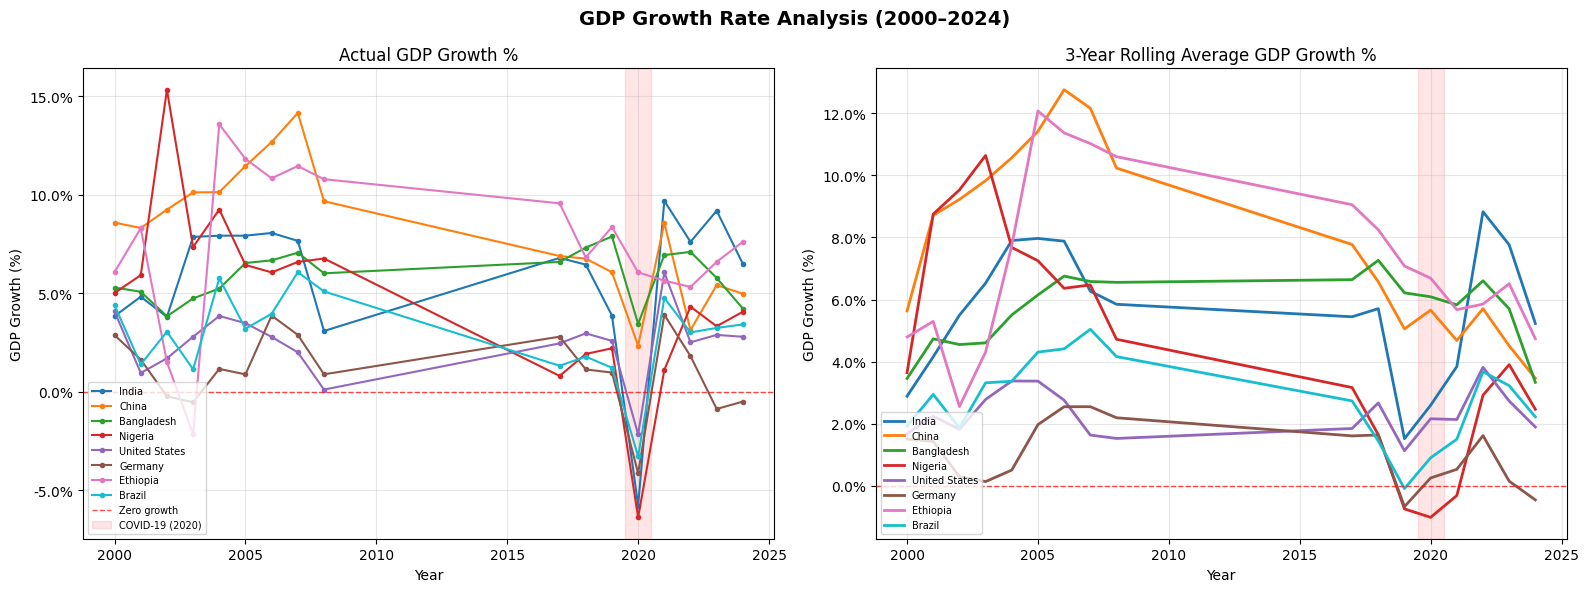

KEY INSIGHTS

India:
  Avg Growth : 5.84%
  Best Year  : 2021 (9.69%)
  Worst Year : 2020 (-5.78%)
  Recessions : [2020]

China:
  Avg Growth : 8.15%
  Best Year  : 2007 (14.15%)
  Worst Year : 2020 (2.34%)
  Recessions : None

Bangladesh:
  Avg Growth : 5.87%
  Best Year  : 2019 (7.88%)
  Worst Year : 2020 (3.45%)
  Recessions : None

Nigeria:
  Avg Growth : 4.71%
  Best Year  : 2002 (15.33%)
  Worst Year : 2020 (-6.37%)
  Recessions : [2020]

United States:
  Avg Growth : 2.46%
  Best Year  : 2021 (6.06%)
  Worst Year : 2020 (-2.16%)
  Recessions : [2020]

Germany:
  Avg Growth : 1.09%
  Best Year  : 2021 (3.91%)
  Worst Year : 2020 (-4.13%)
  Recessions : [2002, 2003, 2020, 2023, 2024]

Ethiopia:
  Avg Growth : 7.54%
  Best Year  : 2004 (13.57%)
  Worst Year : 2003 (-2.16%)
  Recessions : [2003]

Brazil:
  Avg Growth : 2.91%
  Best Year  : 2007 (6.07%)
  Worst Year : 2020 (-3.28%)
  Recessions : [2020]


In [7]:
colors = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd',
          '#8c564b','#e377c2','#17becf']

# Filter GDP Growth, exclude World
gdp_growth = (
    df_long
    .filter(
        (pl.col('Indicator_Short') == 'GDP Growth %') &
        (pl.col('Country') != 'World')
    )
    .sort('Year')
)

# Pivot for plotting (Year as rows, Country as columns)
gdp_pivot = (
    gdp_growth
    .pivot(on='Country', index='Year', values='Value')
    .sort('Year')
)

countries_gdp = [c for c in gdp_pivot.columns if c != 'Year']

# NumPy rolling 3-year average
years_arr = gdp_pivot['Year'].to_numpy()
rolling_cols = {}
for country in countries_gdp:
    arr = gdp_pivot[country].to_numpy().astype(float)
    rolling_cols[country] = np.convolve(arr, np.ones(3)/3, mode='same')

#Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('GDP Growth Rate Analysis (2000–2024)', fontsize=14, fontweight='bold')

# Plot 1: Actual GDP Growth
ax1 = axes[0]
for i, country in enumerate(countries_gdp):
    vals = gdp_pivot[country].to_numpy()
    ax1.plot(years_arr, vals, marker='o', markersize=3, linewidth=1.5,
             label=country, color=colors[i % len(colors)])

ax1.axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.7, label='Zero growth')
ax1.axvspan(2019.5, 2020.5, alpha=0.1, color='red', label='COVID-19 (2020)')
ax1.set_title('Actual GDP Growth %')
ax1.set_xlabel('Year')
ax1.set_ylabel('GDP Growth (%)')
ax1.legend(fontsize=7, loc='lower left')
ax1.grid(True, alpha=0.3)
ax1.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f%%'))

# Plot 2: 3-Year Rolling Average
ax2 = axes[1]
for i, country in enumerate(countries_gdp):
    ax2.plot(years_arr, rolling_cols[country], linewidth=2,
             label=country, color=colors[i % len(colors)])

ax2.axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.7)
ax2.axvspan(2019.5, 2020.5, alpha=0.1, color='red')
ax2.set_title('3-Year Rolling Average GDP Growth %')
ax2.set_xlabel('Year')
ax2.set_ylabel('GDP Growth (%)')
ax2.legend(fontsize=7, loc='lower left')
ax2.grid(True, alpha=0.3)
ax2.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f%%'))

plt.tight_layout()
plt.show()

#Key insights via NumPy
print("=" * 50)
print("KEY INSIGHTS")
print("=" * 50)
for country in countries_gdp:
    data = gdp_pivot[country].drop_nulls().to_numpy()
    yr_arr = gdp_pivot.filter(pl.col(country).is_not_null())['Year'].to_numpy()
    best_idx  = int(np.argmax(data))
    worst_idx = int(np.argmin(data))
    recession_yrs = yr_arr[data < 0].tolist()
    print(f"\n{country}:")
    print(f"  Avg Growth : {np.mean(data):.2f}%")
    print(f"  Best Year  : {yr_arr[best_idx]} ({data[best_idx]:.2f}%)")
    print(f"  Worst Year : {yr_arr[worst_idx]} ({data[worst_idx]:.2f}%)")
    print(f"  Recessions : {recession_yrs if recession_yrs else 'None'}")

## Poverty vs GDP per Capita Correlation

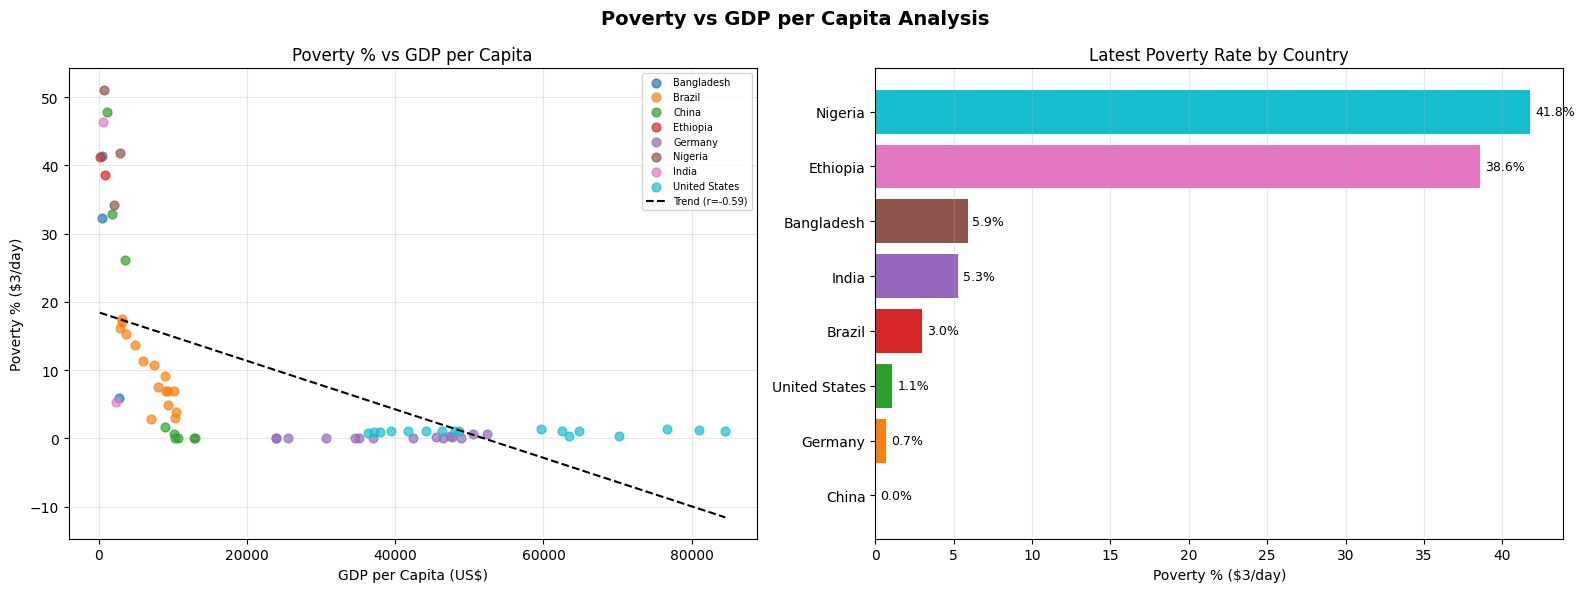


Pearson Correlation (GDP per Capita vs Poverty): -0.5883
Slope    : -0.000355
Intercept: 18.46

Interpretation: Strong negative correlation — higher GDP per capita = lower poverty


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Poverty vs GDP per Capita Analysis', fontsize=14, fontweight='bold')

# Filter each indicator
poverty = (
    df_long
    .filter(
        (pl.col('Indicator_Short') == 'Poverty %') &
        (pl.col('Country') != 'World')
    )
    .select(['Country', 'Year', 'Value'])
    .rename({'Value': 'Poverty'})
)

gdp_pc = (
    df_long
    .filter(
        (pl.col('Indicator_Short') == 'GDP per Capita') &
        (pl.col('Country') != 'World')
    )
    .select(['Country', 'Year', 'Value'])
    .rename({'Value': 'GDP_PC'})
)

# Join on Country + Year
merged = poverty.join(gdp_pc, on=['Country', 'Year'], how='inner').drop_nulls()

# NumPy Pearson correlation
x = merged['GDP_PC'].to_numpy()
y = merged['Poverty'].to_numpy()
corr = np.corrcoef(x, y)[0, 1]

# NumPy manual linear regression
x_norm    = x - x.mean()
slope     = np.sum(x_norm * (y - y.mean())) / np.sum(x_norm ** 2)
intercept = y.mean() - slope * x.mean()
x_line    = np.linspace(x.min(), x.max(), 100)
y_line    = slope * x_line + intercept

# Scatter + regression
ax1 = axes[0]
for i, country in enumerate(merged['Country'].unique().to_list()):
    sub = merged.filter(pl.col('Country') == country)
    ax1.scatter(sub['GDP_PC'].to_numpy(), sub['Poverty'].to_numpy(),
                label=country, color=colors[i % len(colors)], alpha=0.7, s=40)

ax1.plot(x_line, y_line, 'k--', linewidth=1.5, label=f'Trend (r={corr:.2f})')
ax1.set_title('Poverty % vs GDP per Capita')
ax1.set_xlabel('GDP per Capita (US$)')
ax1.set_ylabel('Poverty % ($3/day)')
ax1.legend(fontsize=7)
ax1.grid(True, alpha=0.3)

# Plot 2: Latest poverty per country
ax2 = axes[1]
latest = (
    merged
    .sort('Year')
    .group_by('Country', maintain_order=True)
    .last()
    .sort('Poverty')
)
bars = ax2.barh(
    latest['Country'].to_list(),
    latest['Poverty'].to_numpy(),
    color=colors[:latest.height]
)
ax2.set_title('Latest Poverty Rate by Country')
ax2.set_xlabel('Poverty % ($3/day)')
ax2.grid(True, alpha=0.3, axis='x')
for bar, val in zip(bars, latest['Poverty'].to_numpy()):
    ax2.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print(f"\nPearson Correlation (GDP per Capita vs Poverty): {corr:.4f}")
print(f"Slope    : {slope:.6f}")
print(f"Intercept: {intercept:.2f}")
print("\nInterpretation:", end=" ")
if corr < -0.5:
    print("Strong negative correlation — higher GDP per capita = lower poverty")
elif corr < 0:
    print("Weak negative correlation")
else:
    print("Positive/no correlation")


## HDI Proxy Composite Score

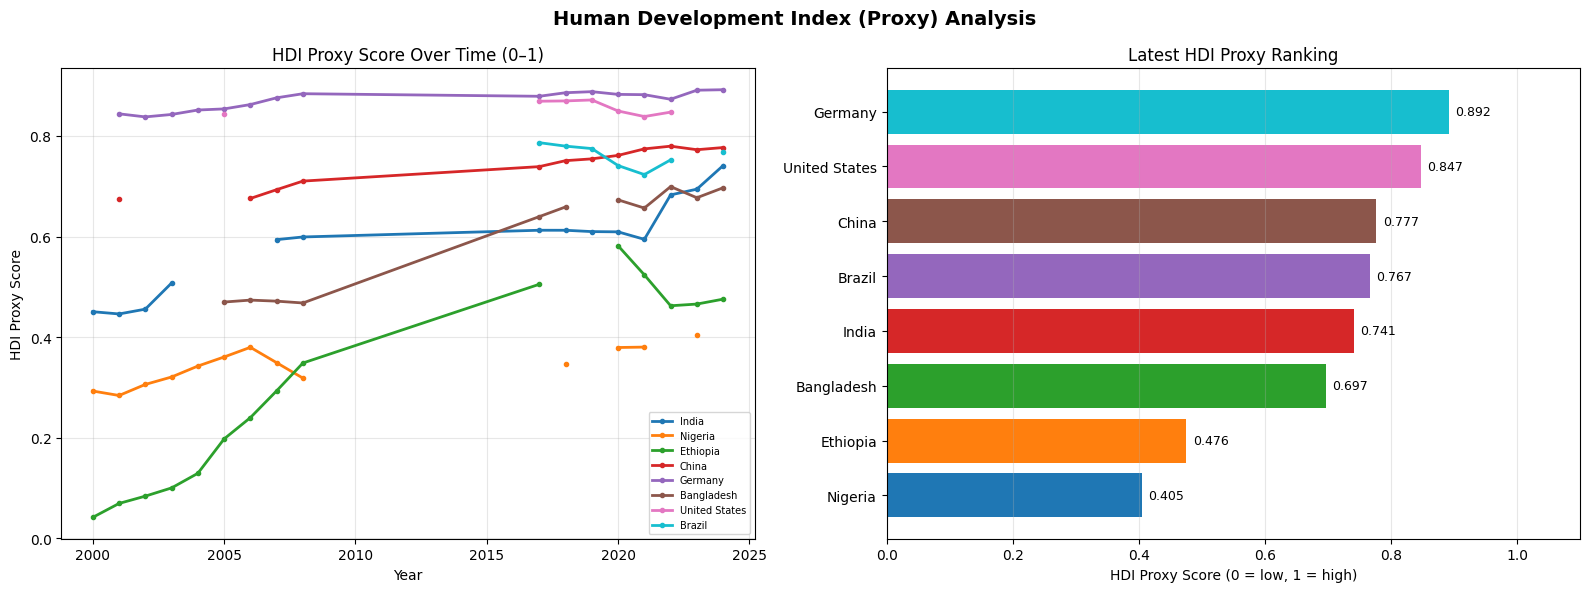


HDI Proxy Rankings (Latest Year):
-----------------------------------
  1. Germany         0.8919
  2. United States   0.8474
  3. China           0.7770
  4. Brazil          0.7673
  5. India           0.7412
  6. Bangladesh      0.6971
  7. Ethiopia        0.4757
  8. Nigeria         0.4050


In [9]:
#  Extract 3 component indicators using Polars filter
def get_indicator(df, name):
    return (
        df
        .filter(
            (pl.col('Indicator_Short') == name) &
            (pl.col('Country') != 'World')
        )
        .select(['Country', 'Year', 'Value'])
    )

life_df = get_indicator(df_long, 'Life Expectancy').rename({'Value': 'life'})
edu_df  = get_indicator(df_long, 'School Enrollment %').rename({'Value': 'edu'})
gdp_df  = get_indicator(df_long, 'GDP per Capita').rename({'Value': 'gdp'})

#  Join all 3 on Country + Year
# Polars: chain .join() calls replaces multiple pd.merge()
hdi_df = (
    life_df
    .join(edu_df, on=['Country', 'Year'], how='inner')
    .join(gdp_df, on=['Country', 'Year'], how='inner')
    .drop_nulls()
)

# NumPy min-max normalization
def minmax(arr):
    return (arr - arr.min()) / (arr.max() - arr.min())

life_norm = minmax(hdi_df['life'].to_numpy())
edu_norm  = minmax(hdi_df['edu'].to_numpy())
gdp_norm  = minmax(np.log(hdi_df['gdp'].to_numpy()))  # log to reduce skew
hdi_score = (life_norm + edu_norm + gdp_norm) / 3

# Add computed columns back to Polars DataFrame
# .with_columns(pl.Series(...)) adds numpy array as Polars column
hdi_df = hdi_df.with_columns([
    pl.Series('life_norm', life_norm),
    pl.Series('edu_norm',  edu_norm),
    pl.Series('gdp_norm',  gdp_norm),
    pl.Series('HDI_Proxy', hdi_score)
])

# Pivot for trend plot
hdi_pivot = (
    hdi_df
    .select(['Country', 'Year', 'HDI_Proxy'])
    .pivot(on='Country', index='Year', values='HDI_Proxy')
    .sort('Year')
)

countries_hdi = [c for c in hdi_pivot.columns if c != 'Year']
years_hdi     = hdi_pivot['Year'].to_numpy()

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Human Development Index (Proxy) Analysis', fontsize=14, fontweight='bold')

ax1 = axes[0]
for i, country in enumerate(countries_hdi):
    ax1.plot(years_hdi, hdi_pivot[country].to_numpy(),
             marker='o', markersize=3, linewidth=2,
             label=country, color=colors[i % len(colors)])
ax1.set_title('HDI Proxy Score Over Time (0–1)')
ax1.set_xlabel('Year')
ax1.set_ylabel('HDI Proxy Score')
ax1.legend(fontsize=7)
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
# Latest HDI ranking using Polars
latest_hdi = (
    hdi_df
    .sort('Year')
    .group_by('Country', maintain_order=True)
    .last()
    .sort('HDI_Proxy')
)
bars = ax2.barh(
    latest_hdi['Country'].to_list(),
    latest_hdi['HDI_Proxy'].to_numpy(),
    color=colors[:latest_hdi.height]
)
ax2.set_title('Latest HDI Proxy Ranking')
ax2.set_xlabel('HDI Proxy Score (0 = low, 1 = high)')
ax2.set_xlim(0, 1.1)
ax2.grid(True, alpha=0.3, axis='x')
for bar, val in zip(bars, latest_hdi['HDI_Proxy'].to_numpy()):
    ax2.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

# Rankings
print("\nHDI Proxy Rankings (Latest Year):")
print("-" * 35)
for rank, row in enumerate(
    latest_hdi.sort('HDI_Proxy', descending=True).iter_rows(named=True), 1
):
    print(f"  {rank}. {row['Country']:<15} {row['HDI_Proxy']:.4f}")


## Inflation Outlier Detection (Z-Score)

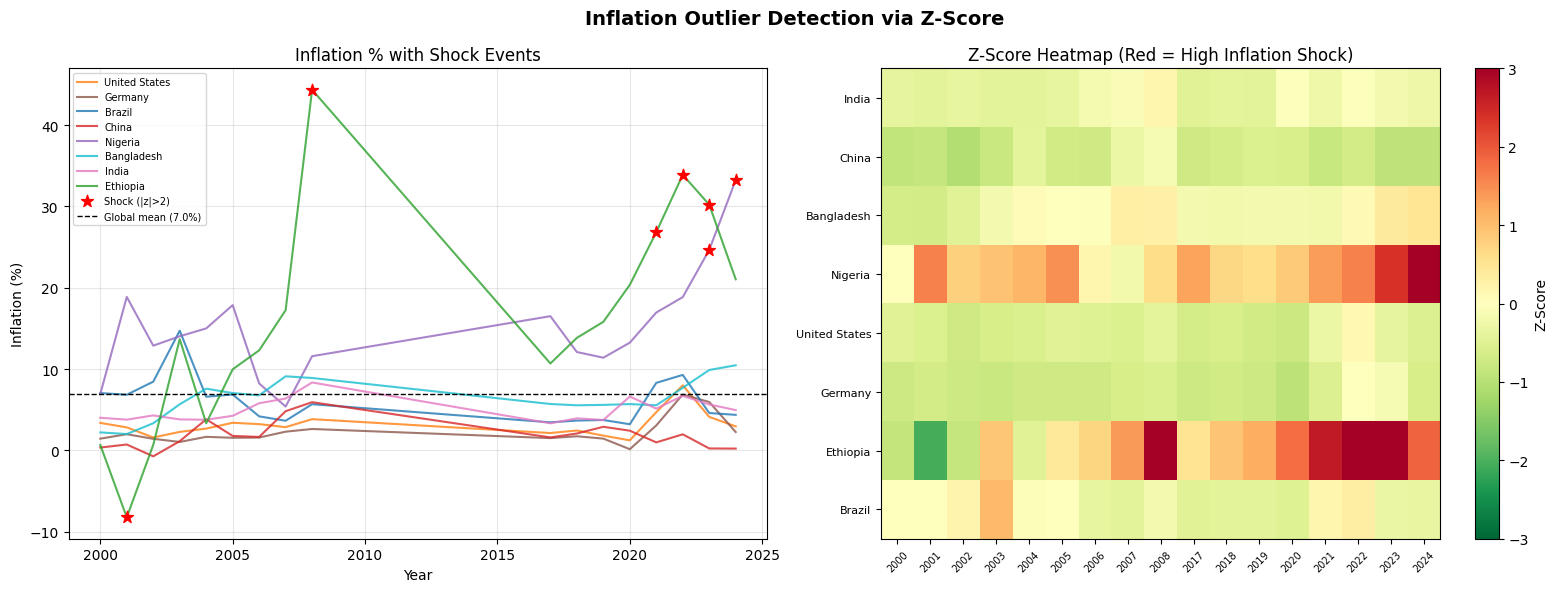


ECONOMIC SHOCK EVENTS DETECTED (|Z-Score| > 2):
  Ethiopia        2008  Inflation:   44.36%  Z-Score:   5.02  [HIGH]
  Ethiopia        2022  Inflation:   33.89%  Z-Score:   3.62  [HIGH]
  Nigeria         2024  Inflation:   33.24%  Z-Score:   3.53  [HIGH]
  Ethiopia        2023  Inflation:   30.22%  Z-Score:   3.12  [HIGH]
  Ethiopia        2021  Inflation:   26.84%  Z-Score:   2.67  [HIGH]
  Nigeria         2023  Inflation:   24.66%  Z-Score:   2.38  [HIGH]
  Ethiopia        2001  Inflation:   -8.24%  Z-Score:  -2.04  [LOW]

Global Mean Inflation : 6.96%
Global Std Deviation  : 7.42%
Total Shocks Detected : 7


In [10]:
# Filter inflation, exclude World
inflation = (
    df_long
    .filter(
        (pl.col('Indicator_Short') == 'Inflation %') &
        (pl.col('Country') != 'World')
    )
)

# Compute Z-Score using Polars expressions
# pl.col().mean() and pl.col().std() compute global stats in one pass
inflation = inflation.with_columns([
    (
        (pl.col('Value') - pl.col('Value').mean()) /
         pl.col('Value').std()
    ).alias('Z_Score')
])

# Flag shocks — |z| > 2
inflation = inflation.with_columns(
    (pl.col('Z_Score').abs() > 2).alias('Shock')
)

# Extract global stats via NumPy
vals      = inflation['Value'].to_numpy()
mean_inf  = np.mean(vals)
std_inf   = np.std(vals)

# Step 5: Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Inflation Outlier Detection via Z-Score', fontsize=14, fontweight='bold')

colors_map = {c: colors[i % len(colors)]
              for i, c in enumerate(inflation['Country'].unique().to_list())}

ax1 = axes[0]
for country in inflation['Country'].unique().to_list():
    sub = inflation.filter(pl.col('Country') == country).sort('Year')
    ax1.plot(sub['Year'].to_numpy(), sub['Value'].to_numpy(),
             label=country, color=colors_map[country], linewidth=1.5, alpha=0.8)

# Highlight shocks
shocks = inflation.filter(pl.col('Shock') == True)
ax1.scatter(shocks['Year'].to_numpy(), shocks['Value'].to_numpy(),
            color='red', zorder=5, s=80, label='Shock (|z|>2)', marker='*')
ax1.axhline(y=mean_inf, color='black', linestyle='--', linewidth=1,
            label=f'Global mean ({mean_inf:.1f}%)')
ax1.set_title('Inflation % with Shock Events')
ax1.set_xlabel('Year')
ax1.set_ylabel('Inflation (%)')
ax1.legend(fontsize=7)
ax1.grid(True, alpha=0.3)

# Z-Score heatmap
ax2 = axes[1]
z_pivot = (
    inflation
    .select(['Country', 'Year', 'Z_Score'])
    .pivot(on='Year', index='Country', values='Z_Score')
)
z_countries  = z_pivot['Country'].to_list()
z_year_cols  = [c for c in z_pivot.columns if c != 'Country']
z_matrix     = z_pivot.select(z_year_cols).to_numpy()

im = ax2.imshow(z_matrix, cmap='RdYlGn_r', aspect='auto', vmin=-3, vmax=3)
ax2.set_xticks(range(len(z_year_cols)))
ax2.set_xticklabels(z_year_cols, rotation=45, fontsize=7)
ax2.set_yticks(range(len(z_countries)))
ax2.set_yticklabels(z_countries, fontsize=8)
ax2.set_title('Z-Score Heatmap (Red = High Inflation Shock)')
plt.colorbar(im, ax=ax2, label='Z-Score')

plt.tight_layout()
plt.show()

# Print shock events
print("\nECONOMIC SHOCK EVENTS DETECTED (|Z-Score| > 2):")
print("=" * 55)
for row in shocks.sort('Z_Score', descending=True).iter_rows(named=True):
    direction = "HIGH" if row['Z_Score'] > 0 else "LOW"
    print(f"  {row['Country']:<15} {row['Year']}  "
          f"Inflation: {row['Value']:>7.2f}%  "
          f"Z-Score: {row['Z_Score']:>6.2f}  [{direction}]")

print(f"\nGlobal Mean Inflation : {mean_inf:.2f}%")
print(f"Global Std Deviation  : {std_inf:.2f}%")
print(f"Total Shocks Detected : {shocks.height}")


## Summary Dashboard


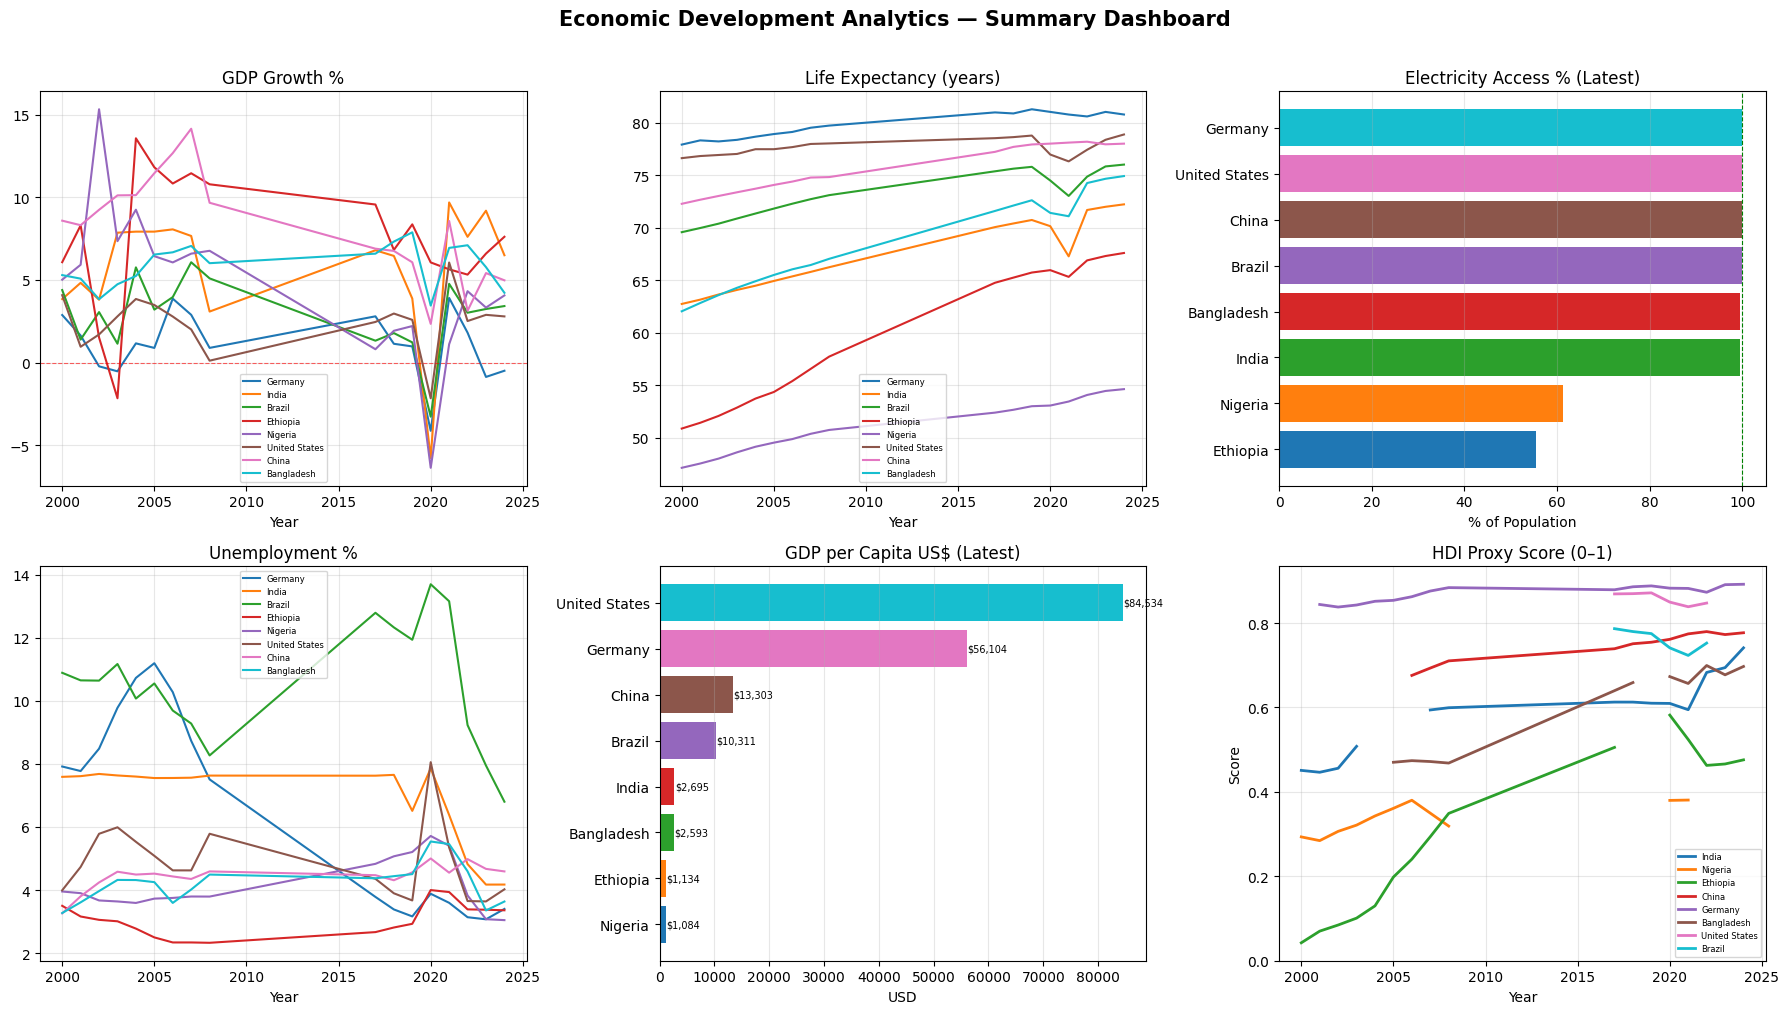


Dashboard saved as 'economic_dashboard.png'

FINAL SUMMARY STATISTICS (numpy)

GDP Growth %:
  Global Mean   : 4.82
  Std Deviation : 3.74
  Min           : -6.37
  Max           : 15.33
  Median        : 4.79

Inflation %:
  Global Mean   : 6.96
  Std Deviation : 7.42
  Min           : -8.24
  Max           : 44.36
  Median        : 4.48

Unemployment %:
  Global Mean   : 5.57
  Std Deviation : 2.65
  Min           : 2.33
  Max           : 13.70
  Median        : 4.51

Life Expectancy:
  Global Mean   : 69.11
  Std Deviation : 9.69
  Min           : 47.14
  Max           : 81.29
  Median        : 72.06


In [11]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Economic Development Analytics — Summary Dashboard',
             fontsize=15, fontweight='bold', y=1.01)

# Get list of non-world countries from Polars
countries_no_world = (
    df_long
    .filter(pl.col('Country') != 'World')
    ['Country']
    .unique()
    .to_list()
)

def get_country_series(indicator, country):
    """Returns (years_array, values_array) for one country + indicator"""
    sub = (
        df_long
        .filter(
            (pl.col('Country') == country) &
            (pl.col('Indicator_Short') == indicator)
        )
        .sort('Year')
    )
    return sub['Year'].to_numpy(), sub['Value'].to_numpy()

def get_latest(indicator):
    """Returns Polars DataFrame with latest value per non-World country"""
    return (
        df_long
        .filter(
            (pl.col('Indicator_Short') == indicator) &
            (pl.col('Country') != 'World')
        )
        .sort('Year')
        .group_by('Country', maintain_order=True)
        .last()
        .sort('Value')
    )

# ── Panel 1: GDP Growth ───────────────────────────────────
ax = axes[0, 0]
for i, c in enumerate(countries_no_world):
    yr, val = get_country_series('GDP Growth %', c)
    ax.plot(yr, val, linewidth=1.5, label=c, color=colors[i % len(colors)])
ax.axhline(0, color='red', linestyle='--', linewidth=0.8, alpha=0.6)
ax.set_title('GDP Growth %')
ax.set_xlabel('Year')
ax.legend(fontsize=6)
ax.grid(True, alpha=0.3)

# ── Panel 2: Life Expectancy ──────────────────────────────
ax = axes[0, 1]
for i, c in enumerate(countries_no_world):
    yr, val = get_country_series('Life Expectancy', c)
    ax.plot(yr, val, linewidth=1.5, label=c, color=colors[i % len(colors)])
ax.set_title('Life Expectancy (years)')
ax.set_xlabel('Year')
ax.legend(fontsize=6)
ax.grid(True, alpha=0.3)

# ── Panel 3: Electricity Access ───────────────────────────
ax = axes[0, 2]
latest_e = get_latest('Electricity Access %')
ax.barh(latest_e['Country'].to_list(), latest_e['Value'].to_numpy(),
        color=colors[:latest_e.height])
ax.set_title('Electricity Access % (Latest)')
ax.set_xlabel('% of Population')
ax.axvline(100, color='green', linestyle='--', linewidth=0.8)
ax.grid(True, alpha=0.3, axis='x')

# ── Panel 4: Unemployment ─────────────────────────────────
ax = axes[1, 0]
for i, c in enumerate(countries_no_world):
    yr, val = get_country_series('Unemployment %', c)
    ax.plot(yr, val, linewidth=1.5, label=c, color=colors[i % len(colors)])
ax.set_title('Unemployment %')
ax.set_xlabel('Year')
ax.legend(fontsize=6)
ax.grid(True, alpha=0.3)

# ── Panel 5: GDP per Capita (Latest) ──────────────────────
ax = axes[1, 1]
latest_g = get_latest('GDP per Capita')
bars = ax.barh(latest_g['Country'].to_list(), latest_g['Value'].to_numpy(),
               color=colors[:latest_g.height])
ax.set_title('GDP per Capita US$ (Latest)')
ax.set_xlabel('USD')
ax.grid(True, alpha=0.3, axis='x')
for bar, val in zip(bars, latest_g['Value'].to_numpy()):
    ax.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
            f'${val:,.0f}', va='center', fontsize=7)

# ── Panel 6: HDI Proxy Trend ──────────────────────────────
ax = axes[1, 2]
for i, country in enumerate(countries_hdi):
    ax.plot(years_hdi, hdi_pivot[country].to_numpy(),
            linewidth=2, label=country, color=colors[i % len(colors)])
ax.set_title('HDI Proxy Score (0–1)')
ax.set_xlabel('Year')
ax.set_ylabel('Score')
ax.legend(fontsize=6)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('economic_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nDashboard saved as 'economic_dashboard.png'")

# ── Final Summary Stats (NumPy) ────────────────────────────
print("\n" + "=" * 55)
print("FINAL SUMMARY STATISTICS (numpy)")
print("=" * 55)

for indicator in ['GDP Growth %', 'Inflation %', 'Unemployment %', 'Life Expectancy']:
    # Polars filter → .to_numpy() for NumPy stats
    data = (
        df_long
        .filter(
            (pl.col('Indicator_Short') == indicator) &
            (pl.col('Country') != 'World')
        )
        ['Value']
        .drop_nulls()
        .to_numpy()
    )
    print(f"\n{indicator}:")
    print(f"  Global Mean   : {np.mean(data):.2f}")
    print(f"  Std Deviation : {np.std(data):.2f}")
    print(f"  Min           : {np.min(data):.2f}")
    print(f"  Max           : {np.max(data):.2f}")
    print(f"  Median        : {np.median(data):.2f}")